# 01. Fundamentals of optimization

**Instructor:** Efraín Padilla — DLR IMF-ASP

**Estimated duration:** approximately 20 minutes.

A physical design problem used to introduce objectives, constraints, and optima.

Run the cells from top to bottom. This notebook is one independent section of the workshop.

In [1]:
# --- Setup --- 

# Restart the kernel before running this cell if Matplotlib was already loaded.
import ipympl
# Enable interactive rotation and zooming for Matplotlib figures in VS Code.
get_ipython().run_line_magic("matplotlib", "ipympl")

# Import the numerical and plotting libraries used throughout the workshop.
import numpy as np
import matplotlib.pyplot as plt

# Choose plotting defaults that keep axes and mathematical curves readable.
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True, "font.size": 11})

## 1. Fundamentals of optimization

Suggested time: 20 minutes.

We begin with a physical design problem so that the meaning of an objective, a constraint, and an optimum is concrete before introducing model parameters.

### 1.1 General description and introductory mathematics

For one example, an affine model combines features with weights and an intercept:

$$\hat y_i=w^Tx_i+b,\qquad \mathcal{L}(w)=\frac{1}{2N}\|Xw-y\|_2^2.$$

These equations introduce the general pattern. The derivation below makes each symbol and operation explicit.

First fix one training example. The vector $x_i$ is what the model receives, and the scalar $y_i$ is the answer we want the model to reproduce. The index $i$ tells us which example we mean; it is not a model parameter. The index runs from $1$ through $N$, where $N$ is the total number of examples.



### Definition

Let the data set be

$$
\mathcal{D}=\{(x_i,y_i)\}_{i=1}^{N},
\qquad x_i\in\mathbb{R}^{d},\quad y_i\in\mathbb{R}^{q}.
$$

Here $\mathcal{D}$ is the entire data set, $x_i$ is the $i$-th input vector, and $y_i$ is its observed target. The notation $x_i\in\mathbb{R}^{d}$ says that each input has $d$ numerical features. The notation $y_i\in\mathbb{R}^{q}$ allows $q$ output values; in most of this notebook $q=1$.

A model is a parameterized map. The symbol $\theta$ collects every number that training is allowed to change. For the simplest linear model, $\theta$ will be the weights and bias; we use $\theta$ here because the same idea will later describe an entire neural network.

$$
\hat y_i=f(x_i;\theta).
$$

The sample loss $\ell(\hat y_i,y_i)$ measures disagreement for one example. The first argument, $\hat y_i$, is the prediction; the second argument, $y_i$, is the observed answer. The empirical loss averages this disagreement over all $N$ examples:

$$
\mathcal{L}(\theta)=\frac{1}{N}\sum_{i=1}^{N}
\ell\left(f(x_i;\theta),y_i\right).
$$

Learning means selecting parameters that make the single scalar objective $\mathcal{L}(\theta)$ small:

$$
\theta^\star=\operatorname*{arg\,min}_{\theta}\mathcal{L}(\theta).
$$

This formulation does not mention neural networks. It applies to linear regression, logistic regression, multilayer perceptrons, and convolutional networks. What changes is the parameterized function, the loss, or the method used to evaluate its gradient.

#### A warm-up optimization problem: designing an aluminium can

Before optimizing a remote-sensing model, consider a familiar design problem. Suppose we want to manufacture a closed cylindrical can that holds a fixed volume $V$ while using as little aluminium as possible. Let $r>0$ be the radius and $h>0$ be the height. The quantity to minimize is the can's surface area:

$$
S(r,h)=2\pi r^2+2\pi rh.
$$

#### Illustration of the aluminium-can optimization problem
<div>
<img src="../assets/aluminium_can_optimization.png" width="500"/>
</div>

*A closed cylindrical can with radius $r$, height $h$, fixed volume $V$, and surface area $S$ to minimize.*

#### Deriving the optimal dimensions

Suggested time: 10 minutes.

The first term is the area of the two circular ends, and the second term is the area of the curved side. The volume constraint is

$$
V=\pi r^2h.
$$

We can use the constraint to eliminate the height:

$$
h(r)=\frac{V}{\pi r^2},
\qquad
S(r)=2\pi r^2+\frac{2V}{r}.
$$

The original two-variable design problem has now become a one-variable optimization problem. To differentiate it, use the power rule $d(r^2)/dr=2r$ and the equivalent form $1/r=r^{-1}$, whose derivative is $-r^{-2}$:

$$
\frac{dS}{dr}
=\frac{d}{dr}\left(2\pi r^2+2Vr^{-1}\right)
=2\pi(2r)+2V(-r^{-2})
=4\pi r-\frac{2V}{r^2}.
$$

At an interior minimum, this first derivative must be zero. Therefore

$$
4\pi r-\frac{2V}{r^2}=0
\quad\Longrightarrow\quad
4\pi r=\frac{2V}{r^2}
\quad\Longrightarrow\quad
4\pi r^3=2V
\quad\Longrightarrow\quad
r^3=\frac{V}{2\pi}.
$$

Therefore

$$
r^\star=\left(\frac{V}{2\pi}\right)^{1/3},
\qquad
h^\star=2r^\star.
$$

Why does the optimum satisfy $h^\star=2r^\star$? This relation is a consequence of the constraint and the first-order optimality condition; it is not an additional assumption. At the optimum,

$$
4\pi(r^\star)^3=2V
\quad\Longrightarrow\quad
V=2\pi(r^\star)^3.
$$

Substituting this result into the volume constraint gives

$$
h^\star=\frac{V}{\pi(r^\star)^2}
=\frac{2\pi(r^\star)^3}{\pi(r^\star)^2}
=2r^\star.
$$

Thus, once the optimal radius is known, the fixed-volume constraint determines the corresponding height, which is exactly twice the radius.

Differentiating once more gives

$$
\frac{d^2S}{dr^2}=4\pi+4Vr^{-3}=4\pi+\frac{4V}{r^3}>0
\qquad (r>0).
$$

The second derivative is positive for every $r>0$, so the objective is strictly convex and this stationary point is the unique minimum. The lesson is the same one we will use for machine learning: define a quantity to minimize, identify the parameters that can change, compute how the objective changes with those parameters, and verify that the result is a minimum.

#### Demonstration: explore the can objective

Suggested time: 10 minutes.

Change the volume below and observe how the optimal radius, height, and material requirement change. This one-dimensional objective is easier to inspect than a neural-network objective. Later, the scalar design variable $r$ will be replaced by a vector of trainable model parameters $\theta$.

#### Visualization guide: aluminium-can objective

This plot shows how the required surface area changes with the can radius while the volume remains fixed. The horizontal axis is the radius $r$, the vertical axis is the material requirement $S(r)$, and the marked point is the analytical optimum.

Look for the U-shaped objective and the fact that the minimum is unique. You can change `can_volume` and the range in `radius_candidates` to see how the optimum moves.

**Open question:** Why does increasing the fixed volume change both the optimal radius and height, and what does the curvature near the minimum tell us about sensitivity to manufacturing errors?

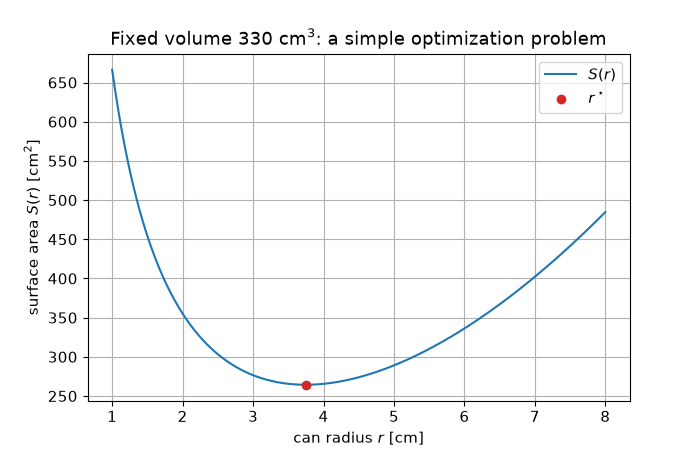

optimal radius = 3.745 cm
optimal height = 7.490 cm


In [2]:
# Choose a can volume in cubic centimetres and evaluate the material objective.
can_volume = 330.0
radius_candidates = np.linspace(1.0, 8.0, 500)
surface_area = 2.0 * np.pi * radius_candidates**2 + 2.0 * can_volume / radius_candidates
optimal_radius = (can_volume / (2.0 * np.pi)) ** (1.0 / 3.0)
optimal_height = 2.0 * optimal_radius

# Plot the one-dimensional objective and mark the analytic minimizer.
plt.figure(figsize=(7, 4.5))
plt.plot(radius_candidates, surface_area, label="$S(r)$")
plt.scatter([optimal_radius], [2.0 * np.pi * optimal_radius**2 + 2.0 * can_volume / optimal_radius],
            color="tab:red", zorder=3, label="$r^\\star$")
plt.xlabel("can radius $r$ [cm]")
plt.ylabel("surface area $S(r)$ [cm$^2$]")
plt.title(f"Fixed volume {can_volume:.0f} cm$^3$: a simple optimization problem")
plt.legend()
plt.show()
print(f"optimal radius = {optimal_radius:.3f} cm")
print(f"optimal height = {optimal_height:.3f} cm")